# **Cloud Infrastructure Resource Optimization and Performance Analytics**

# Exploratory Data Analysis, Data Cleaning & Feature Engineering

**Project Objective:**
This project analyses cloud virtual machine (VM) resource utilization data to identify workload patterns, improve operational efficiency, detect anomalies, and prepare the dataset for business analysis using SQL and Power BI.

# 1. Import Libraries & Load Dataset

In [43]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Project 2 Cloud Infra Analysis\vmCloud_data.csv")

# 2. Initial Dataset Inspection

In [3]:
df.shape                    

(2000000, 12)

In [ ]:
df.dtypes

In [5]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [6]:
df.isnull().sum()

vm_id                        200638
timestamp                    200666
cpu_usage                    199038
memory_usage                 200510
network_traffic              199481
power_consumption            200271
num_executed_instructions    199686
execution_time               199827
energy_efficiency            200042
task_type                    199962
task_priority                199433
task_status                  200306
dtype: int64

In [7]:
df.nunique()

vm_id                        1799362
timestamp                    1708964
cpu_usage                    1800962
memory_usage                 1799490
network_traffic              1800519
power_consumption            1799729
num_executed_instructions      10000
execution_time               1800173
energy_efficiency            1799958
task_type                          3
task_priority                      3
task_status                        3
dtype: int64

In [8]:
df['task_type'].value_counts()

task_type
io         600695
network    600613
compute    598730
Name: count, dtype: int64

In [9]:
df['task_priority'].value_counts() 

task_priority
medium    600700
high      600460
low       599407
Name: count, dtype: int64

In [10]:
df['task_status'].value_counts() 

task_status
waiting      600358
running      600217
completed    599119
Name: count, dtype: int64

In [11]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [12]:
df['timestamp'].min(), df['timestamp'].max() 

(Timestamp('2023-01-01 00:00:09'), Timestamp('2023-07-20 12:04:18'))

In [13]:
df.describe()

,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency
count,1799334,1.800962e+06,1.799490e+06,1.800519e+06,1.799729e+06,1.800314e+06,1.800173e+06,1.799958e+06
mean,2023-04-11 07:19:55.175783168,5.001223e+01,4.998190e+01,5.000076e+02,2.500584e+02,5.001897e+03,4.997133e+01,5.002524e-01
min,2023-01-01 00:00:09,7.071203e-05,2.516784e-06,1.890490e-04,1.923802e-04,0.000000e+00,1.036192e-06,1.258445e-07
25%,2023-02-20 04:34:56.249999872,2.497675e+01,2.500378e+01,2.500669e+02,1.249695e+02,2.504000e+03,2.497908e+01,2.501631e-01
50%,2023-04-11 07:56:02.500000,5.005476e+01,4.997609e+01,5.000076e+02,2.502472e+02,5.002000e+03,4.996407e+01,5.003692e-01
75%,2023-05-31 10:45:20.249999872,7.502934e+01,7.495588e+01,7.498175e+02,3.751069e+02,7.502000e+03,7.497650e+01,7.503617e-01
max,2023-07-20 12:04:18,9.999997e+01,9.999993e+01,9.999998e+02,4.999993e+02,9.999000e+03,9.999999e+01,1.000000e+00
std,NaN,2.887661e+01,2.885326e+01,2.885793e+02,1.443634e+02,2.885247e+03,2.886130e+01,2.886669e-01


# 3. Data Cleaning

## **Objective**

Improve data quality by removing inconsistencies and preparing the dataset for analysis.

 ## Cleaning includes:

* Removing duplicate records
* Handling missing values
* Treating invalid values
* Standardising data

In [14]:
df = df.drop_duplicates()

In [15]:
for col in ['cpu_usage','memory_usage','network_traffic','power_consumption',
            'num_executed_instructions','execution_time','energy_efficiency']:
    df[col + '_was_missing'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [16]:
for col in ['task_type','task_priority','task_status']:
    df[col] = df[col].fillna('unknown')

In [17]:
df = df.dropna(subset=['vm_id','timestamp'])

In [18]:
df['cpu_usage'] = df['cpu_usage'].clip(0, 100)
df['memory_usage'] = df['memory_usage'].clip(0, 100)


In [19]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,cpu_usage_was_missing,memory_usage_was_missing,network_traffic_was_missing,power_consumption_was_missing,num_executed_instructions_was_missing,execution_time_was_missing,energy_efficiency_was_missing
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,0,0,0,0,0,0,0
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,500.007595,362.273569,5348.0,41.396040,0.349856,io,high,completed,0,0,1,0,0,0,0
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,50.054758,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,1,0,0,0,0,0,0
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,500.007595,195.639954,5876.0,16.456670,0.529511,compute,high,completed,0,0,1,0,0,0,0
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,49.976089,500.007595,359.451537,3361.0,55.307992,0.351907,unknown,medium,waiting,0,1,1,0,0,0,0


In [20]:
df.to_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Project 2 Cloud Infra Analysis\vmCloud_Data_Clean.csv", index=False)

# 4. Feature Engineering

## Objective

Create new business-oriented features that provide deeper operational insights beyond the original dataset.

These engineered features support anomaly detection, workload analysis, and infrastructure optimisation.

In [21]:
def classify_utilization(row):
    if row['cpu_usage'] < 20 and row['memory_usage'] < 20:
        return 'Underutilized'
    elif row['cpu_usage'] > 80 or row['memory_usage'] > 80:
        return 'Overloaded'
    else:
        return 'Optimal'

In [22]:
df['utilization_category'] = df.apply(classify_utilization, axis=1)

In [23]:
df['efficiency_score'] = df['num_executed_instructions'] / df['power_consumption'].replace(0, 0.01)

In [24]:
Q1 = df['efficiency_score'].quantile(0.25)
Q3 = df['efficiency_score'].quantile(0.75)
IQR = Q3 - Q1
df['is_anomaly'] = ((df['efficiency_score'] < Q1 - 1.5*IQR) |
                     (df['efficiency_score'] > Q3 + 1.5*IQR)).astype(int)

In [25]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

In [26]:
df['sla_risk'] = ((df['task_priority'] == 'high') & (df['task_status'] == 'waiting')).astype(int)

# 5. Load Final Dataset
## Load the cleaned and feature-engineered dataset for exploratory data analysis.

In [27]:
df.to_csv(
    r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Project 2 Cloud Infra Analysis\vmCloud_Data_Feature_Engineered.csv",
    index=False
)

In [28]:
df2 = pd.read_csv(r"C:\Users\Varun Raghu\ENGINEERING NOTES\Data Analyst\Project 2 Cloud Infra Analysis\cloud_vm_metrics.csv")

In [29]:
df2.shape

(1618908, 26)

In [30]:
df2.nunique()

vm_id                                    1618908
timestamp                                1545749
cpu_usage                                1457514
memory_usage                             1456382
network_traffic                          1457379
power_consumption                        1456761
num_executed_instructions                  10000
execution_time                           1457400
energy_efficiency                        1457123
task_type                                      4
task_priority                                  4
task_status                                    4
cpu_usage_was_missing                          2
memory_usage_was_missing                       2
network_traffic_was_missing                    2
power_consumption_was_missing                  2
num_executed_instructions_was_missing          2
execution_time_was_missing                     2
energy_efficiency_was_missing                  2
utilization_category                           3
efficiency_score    

# 7. Exploratory Data Analysis (EDA)


   ## Objective

### The purpose of EDA is to understand the characteristics of the processed dataset before performing SQL analysis and dashboard development.

### EDA helps to:

* Understand feature distributions
* Validate engineered features
* Examine workload characteristics
* Identify unusual observations
* Gain confidence in the prepared dataset

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df.shape
df.info()
df.describe()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 1618908 entries, 0 to 1999999
Data columns (total 26 columns):
 #   Column                                 Non-Null Count    Dtype         
---  ------                                 --------------    -----         
 0   vm_id                                  1618908 non-null  object        
 1   timestamp                              1618908 non-null  datetime64[ns]
 2   cpu_usage                              1618908 non-null  float64       
 3   memory_usage                           1618908 non-null  float64       
 4   network_traffic                        1618908 non-null  float64       
 5   power_consumption                      1618908 non-null  float64       
 6   num_executed_instructions              1618908 non-null  float64       
 7   execution_time                         1618908 non-null  float64       
 8   energy_efficiency                      1618908 non-null  float64       
 9   task_type                              1

vm_id                                    1618908
timestamp                                1545749
cpu_usage                                1457514
memory_usage                             1456382
network_traffic                          1457379
power_consumption                        1456761
num_executed_instructions                  10000
execution_time                           1457400
energy_efficiency                        1457123
task_type                                      4
task_priority                                  4
task_status                                    4
cpu_usage_was_missing                          2
memory_usage_was_missing                       2
network_traffic_was_missing                    2
power_consumption_was_missing                  2
num_executed_instructions_was_missing          2
execution_time_was_missing                     2
energy_efficiency_was_missing                  2
utilization_category                           3
efficiency_score    

In [33]:
df.isnull().sum()


vm_id                                    0
timestamp                                0
cpu_usage                                0
memory_usage                             0
network_traffic                          0
power_consumption                        0
num_executed_instructions                0
execution_time                           0
energy_efficiency                        0
task_type                                0
task_priority                            0
task_status                              0
cpu_usage_was_missing                    0
memory_usage_was_missing                 0
network_traffic_was_missing              0
power_consumption_was_missing            0
num_executed_instructions_was_missing    0
execution_time_was_missing               0
energy_efficiency_was_missing            0
utilization_category                     0
efficiency_score                         0
is_anomaly                               0
date                                     0
hour       

In [34]:
df.duplicated().sum()


np.int64(0)

In [35]:
df.dtypes

vm_id                                            object
timestamp                                datetime64[ns]
cpu_usage                                       float64
memory_usage                                    float64
network_traffic                                 float64
power_consumption                               float64
num_executed_instructions                       float64
execution_time                                  float64
energy_efficiency                               float64
task_type                                        object
task_priority                                    object
task_status                                      object
cpu_usage_was_missing                             int64
memory_usage_was_missing                          int64
network_traffic_was_missing                       int64
power_consumption_was_missing                     int64
num_executed_instructions_was_missing             int64
execution_time_was_missing                      

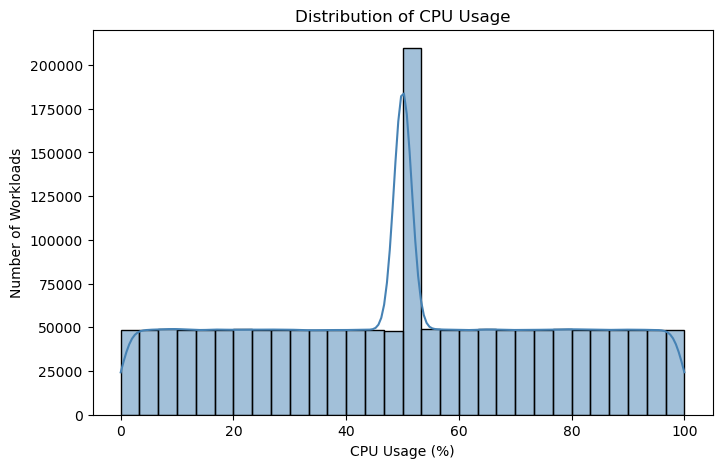

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="cpu_usage",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of CPU Usage")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Number of Workloads")

plt.show()

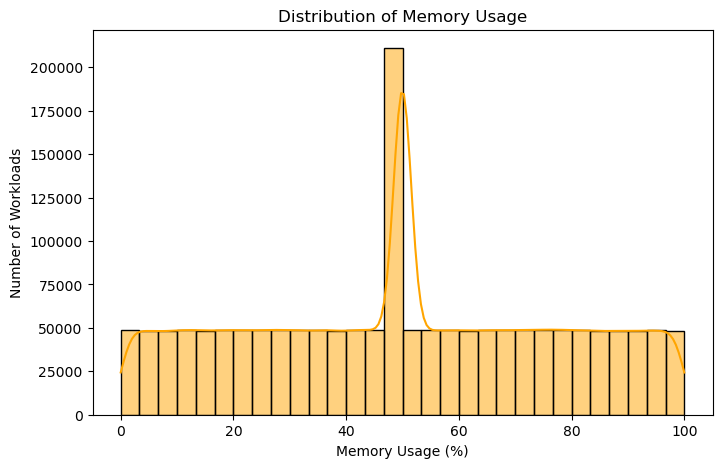

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="memory_usage",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Memory Usage")
plt.xlabel("Memory Usage (%)")
plt.ylabel("Number of Workloads")

plt.show()

C:\Users\Varun Raghu\AppData\Local\Temp\ipykernel_35892\3297681437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


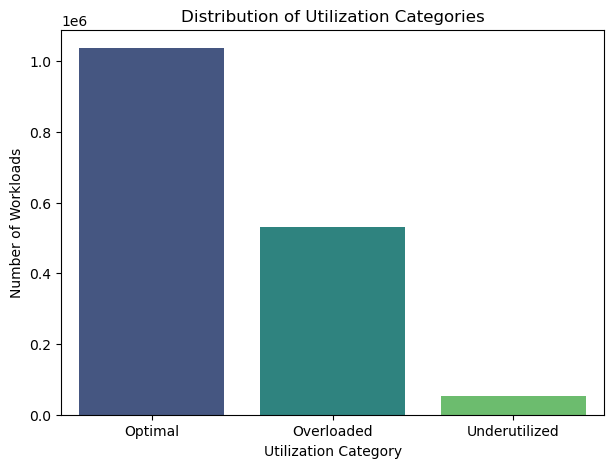

In [38]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="utilization_category",
    palette="viridis"
)

plt.title("Distribution of Utilization Categories")
plt.xlabel("Utilization Category")
plt.ylabel("Number of Workloads")

plt.show()

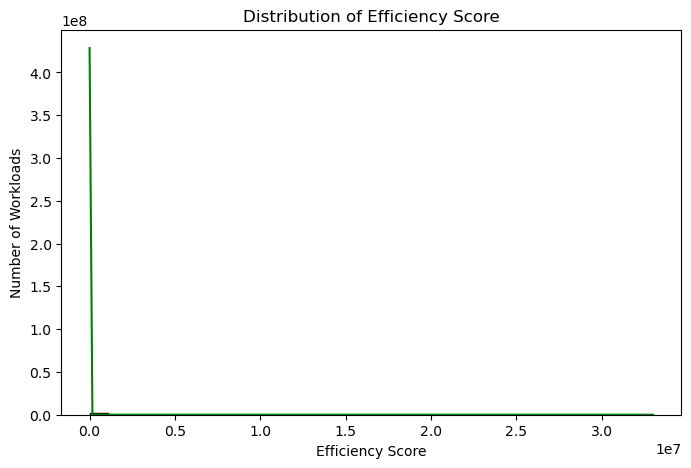

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="efficiency_score",
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Efficiency Score")
plt.xlabel("Efficiency Score")
plt.ylabel("Number of Workloads")

plt.show()

C:\Users\Varun Raghu\AppData\Local\Temp\ipykernel_35892\1011432199.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


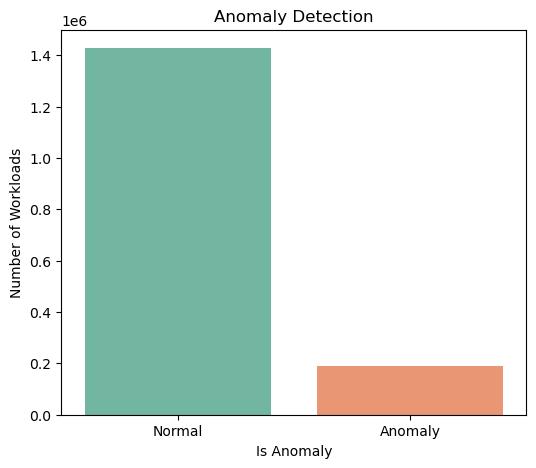

In [40]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="is_anomaly",
    palette="Set2"
)

plt.title("Anomaly Detection")
plt.xlabel("Is Anomaly")
plt.ylabel("Number of Workloads")

plt.xticks([0,1],["Normal","Anomaly"])

plt.show()

C:\Users\Varun Raghu\AppData\Local\Temp\ipykernel_35892\2378361177.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


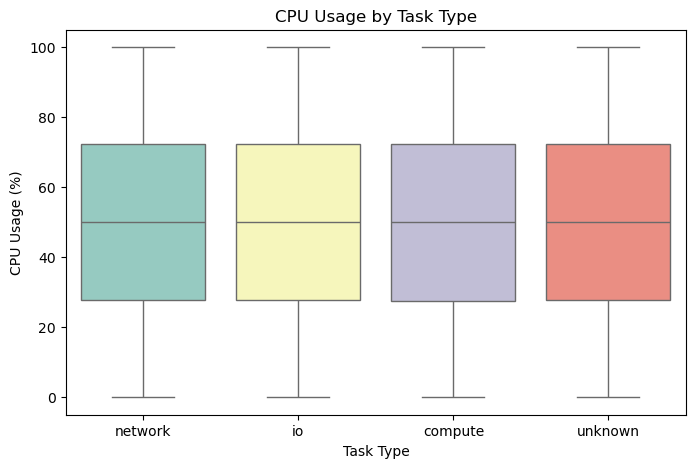

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="task_type",
    y="cpu_usage",
    palette="Set3"
)

plt.title("CPU Usage by Task Type")
plt.xlabel("Task Type")
plt.ylabel("CPU Usage (%)")

plt.show()

C:\Users\Varun Raghu\AppData\Local\Temp\ipykernel_35892\2438766178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


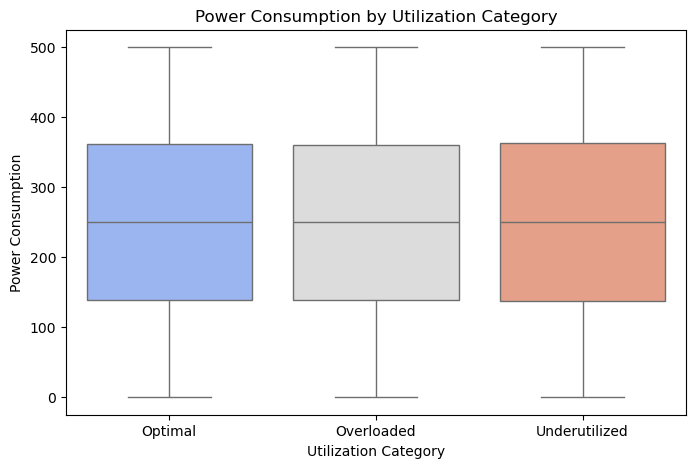

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="utilization_category",
    y="power_consumption",
    palette="coolwarm"
)

plt.title("Power Consumption by Utilization Category")
plt.xlabel("Utilization Category")
plt.ylabel("Power Consumption")

plt.show()

# EDA Summary
### Key Findings
* The processed dataset contains over 1.6 million cloud VM execution records.
* Resource utilisation metrics were successfully cleaned and validated.
* Most workloads fall within the Optimal utilisation category.
* Anomaly detection identified a relatively small proportion of unusual workloads.
* Engineered features such as Efficiency Score, Utilization Category, and SLA Risk provide additional analytical value beyond the raw dataset.

# Overall EDA Summary
## Key Insights
* The cleaned dataset contains over 1.6 million cloud VM execution records covering resource utilisation, workload characteristics, and engineered operational metrics.
* Resource utilisation metrics span a broad range of operating conditions, providing sufficient variation for further analysis.
* Most workloads operate within the Optimal utilization category, indicating generally balanced infrastructure usage.
* The engineered Efficiency Score effectively distinguishes typical workloads from unusually efficient executions.
* Anomaly detection identified a relatively small subset of workloads requiring additional investigation.
* No strong relationships were observed between some variables, which is consistent with the characteristics of the synthetic dataset.

# Business Recommendations
* Continuously monitor overloaded workloads to reduce the risk of SLA violations.
* Use utilisation categories to support automated workload balancing and capacity planning.
* Incorporate anomaly detection into operational monitoring pipelines to identify unusual resource behaviour early.
* Extend efficiency monitoring with additional infrastructure metrics to improve performance optimisation.
* Leverage the cleaned and feature-engineered dataset for SQL-based business analysis and Power BI dashboard development.